# 📦 Forecast Accuracy Assessment — Medical Devices Supply Chain
## Statistical vs Consensus Forecast + ML Model Improvement


**Tools:** Python · pandas · scikit-learn · matplotlib · seaborn  


### 1. IMPORT LIBRARIES


In [13]:
import pandas as pd
import numpy as np

# Graphs
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [41]:
# LOAD DATA

df = pd.read_excel('Medical_Device_Forecast_Data.xlsx')

df.head()


,Product_ID,Category,Region,Month,Actual_Sales,ERP_Stat_FC,Consensus_FC,Stockout_Days,Promotion_Flag,In_Stock_Flag,Promo_Uplift_Factor,Bias_Adjusted_Stat_FC
0,SKU-100,Orthopedic Screws,APAC,2024-11,116,332,540,15,No,No,1.0,332.0
1,SKU-100,Infusion Pumps,North America,2024-07,269,127,291,5,No,No,1.0,127.0
2,SKU-100,Orthopedic Screws,LATAM,2025-02,512,258,523,0,Yes,Yes,1.3,335.4
3,SKU-100,Orthopedic Screws,APAC,2025-08,474,158,399,0,No,Yes,1.0,158.0
4,SKU-100,Orthopedic Screws,APAC,2024-04,563,262,614,0,Yes,Yes,1.3,340.6


### 2. DATA UNDERSTANDING

In [43]:
# Structure
df.info()

# Summary stats
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product_ID             1000 non-null   str    
 1   Category               1000 non-null   str    
 2   Region                 1000 non-null   str    
 3   Month                  1000 non-null   str    
 4   Actual_Sales           1000 non-null   int64  
 5   ERP_Stat_FC            1000 non-null   int64  
 6   Consensus_FC           1000 non-null   int64  
 7   Stockout_Days          1000 non-null   int64  
 8   Promotion_Flag         1000 non-null   str    
 9   In_Stock_Flag          1000 non-null   str    
 10  Promo_Uplift_Factor    1000 non-null   float64
 11  Bias_Adjusted_Stat_FC  1000 non-null   float64
dtypes: float64(2), int64(4), str(6)
memory usage: 132.6 KB


Product_ID               0
Category                 0
Region                   0
Month                    0
Actual_Sales             0
ERP_Stat_FC              0
Consensus_FC             0
Stockout_Days            0
Promotion_Flag           0
In_Stock_Flag            0
Promo_Uplift_Factor      0
Bias_Adjusted_Stat_FC    0
dtype: int64

In [44]:
df.head()

,Product_ID,Category,Region,Month,Actual_Sales,ERP_Stat_FC,Consensus_FC,Stockout_Days,Promotion_Flag,In_Stock_Flag,Promo_Uplift_Factor,Bias_Adjusted_Stat_FC
0,SKU-100,Orthopedic Screws,APAC,2024-11,116,332,540,15,No,No,1.0,332.0
1,SKU-100,Infusion Pumps,North America,2024-07,269,127,291,5,No,No,1.0,127.0
2,SKU-100,Orthopedic Screws,LATAM,2025-02,512,258,523,0,Yes,Yes,1.3,335.4
3,SKU-100,Orthopedic Screws,APAC,2025-08,474,158,399,0,No,Yes,1.0,158.0
4,SKU-100,Orthopedic Screws,APAC,2024-04,563,262,614,0,Yes,Yes,1.3,340.6


In [45]:
print(df[['Actual_Sales', 'ERP_Stat_FC', 'Consensus_FC']].describe().round(2))
df['Promotion_Flag'] = df['Promotion_Flag'].map({'Yes': 1, 'No': 0})

       Actual_Sales  ERP_Stat_FC  Consensus_FC
count       1000.00      1000.00       1000.00
mean         151.45        96.12        197.68
std          158.47        76.37        159.45
min            0.00        15.00          5.00
25%           32.00        36.00         80.00
50%          101.00        74.00        158.00
75%          219.25       130.00        267.25
max          599.00       348.00        648.00


In [46]:
df.head()

,Product_ID,Category,Region,Month,Actual_Sales,ERP_Stat_FC,Consensus_FC,Stockout_Days,Promotion_Flag,In_Stock_Flag,Promo_Uplift_Factor,Bias_Adjusted_Stat_FC
0,SKU-100,Orthopedic Screws,APAC,2024-11,116,332,540,15,0,No,1.0,332.0
1,SKU-100,Infusion Pumps,North America,2024-07,269,127,291,5,0,No,1.0,127.0
2,SKU-100,Orthopedic Screws,LATAM,2025-02,512,258,523,0,1,Yes,1.3,335.4
3,SKU-100,Orthopedic Screws,APAC,2025-08,474,158,399,0,0,Yes,1.0,158.0
4,SKU-100,Orthopedic Screws,APAC,2024-04,563,262,614,0,1,Yes,1.3,340.6


### 3. Creating Required columns

In [47]:
# Errors
df['Stat_Error'] = df['ERP_Stat_FC'] - df['Actual_Sales']
df['Cons_Error'] = df['Consensus_FC'] - df['Actual_Sales']

# Absolute Errors
df['Stat_Abs_Error'] = abs(df['Stat_Error'])
df['Cons_Abs_Error'] = abs(df['Cons_Error'])
# Fixing object columns


# check the data
df.head()

,Product_ID,Category,Region,Month,Actual_Sales,ERP_Stat_FC,Consensus_FC,Stockout_Days,Promotion_Flag,In_Stock_Flag,Promo_Uplift_Factor,Bias_Adjusted_Stat_FC,Stat_Error,Cons_Error,Stat_Abs_Error,Cons_Abs_Error
0,SKU-100,Orthopedic Screws,APAC,2024-11,116,332,540,15,0,No,1.0,332.0,216,424,216,424
1,SKU-100,Infusion Pumps,North America,2024-07,269,127,291,5,0,No,1.0,127.0,-142,22,142,22
2,SKU-100,Orthopedic Screws,LATAM,2025-02,512,258,523,0,1,Yes,1.3,335.4,-254,11,254,11
3,SKU-100,Orthopedic Screws,APAC,2025-08,474,158,399,0,0,Yes,1.0,158.0,-316,-75,316,75
4,SKU-100,Orthopedic Screws,APAC,2024-04,563,262,614,0,1,Yes,1.3,340.6,-301,51,301,51


### 4. EDA (Exploratory Data Analysis)

####  Distribution of Demand

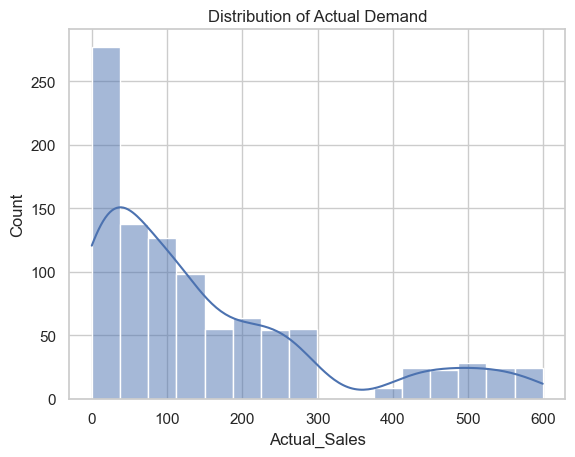

In [48]:
plt.figure()
sns.histplot(df['Actual_Sales'], kde=True)
plt.title("Distribution of Actual Demand")
plt.show()

#### Actual VS Forecast

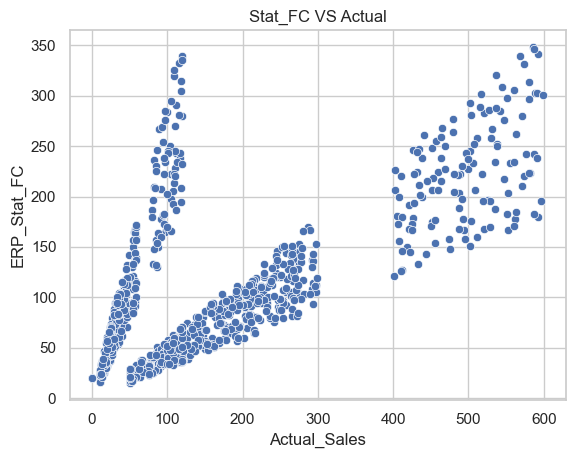

In [49]:
plt.figure()
sns.scatterplot(x=df['Actual_Sales'], y=df['ERP_Stat_FC'])
plt.title("Stat_FC VS Actual")
plt.show()

#### Error Distribution

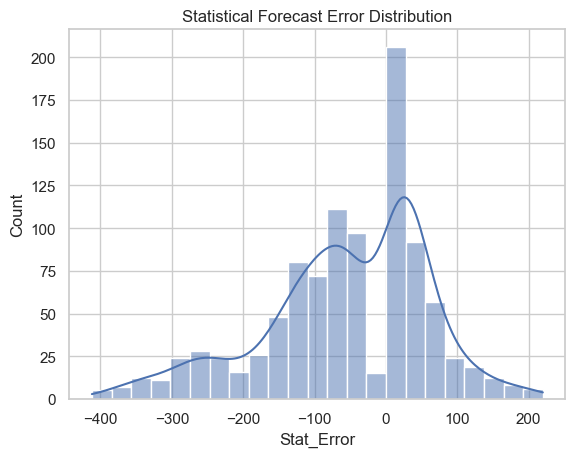

In [50]:
plt.figure()
sns.histplot(df['Stat_Error'], kde=True)
plt.title("Statistical Forecast Error Distribution")
plt.show()


#### Promotion Impact

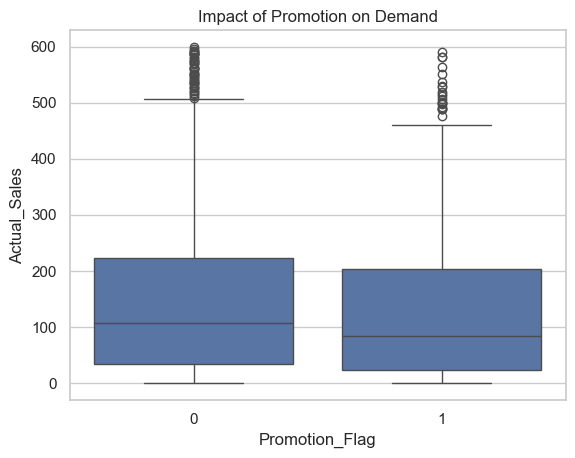

In [51]:
plt.figure()
sns.boxplot(x='Promotion_Flag', y='Actual_Sales', data=df)
plt.title("Impact of Promotion on Demand")
plt.show()

#### Stockout Impact

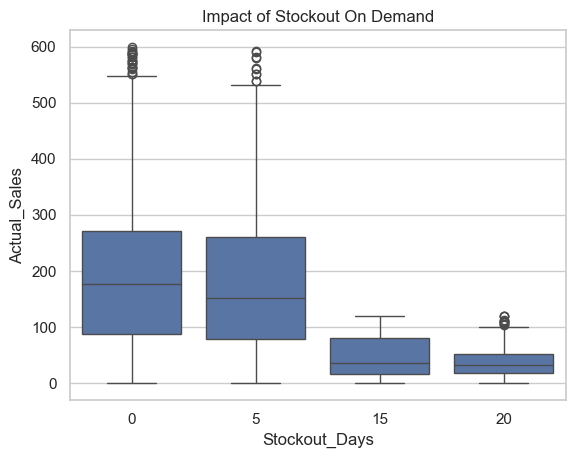

In [52]:
plt.figure()
sns.boxplot(x='Stockout_Days', y='Actual_Sales', data=df)
plt.title('Impact of Stockout On Demand')
plt.show()

#### Correlation Heatmap

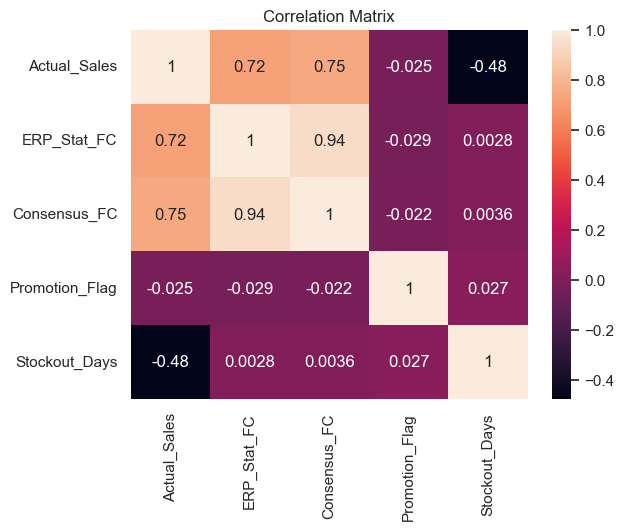

In [53]:
plt.figure()
sns.heatmap(df[['Actual_Sales', 'ERP_Stat_FC', 'Consensus_FC', 'Promotion_Flag','Stockout_Days']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## 5.METRICS FUNCTIONS

In [54]:
def WAPE(actual, forecast):
    return np.sum(np.abs(actual - forecast)) / np.sum(actual)

def MAE(actual, forecast):
    return np.mean(np.abs(actual - forecast))

def Bias(actual, forecast):
    return np.mean(forecast - actual)

In [55]:
print("Statistical Forecast:")
print("WAPE:", WAPE(df['Actual_Sales'], df['ERP_Stat_FC']))
print("MAE:", MAE(df['Actual_Sales'], df['ERP_Stat_FC']))
print("Bias:", Bias(df['Actual_Sales'], df['ERP_Stat_FC']))

print("\nConsensus Forecast:")
print("WAPE:", WAPE(df['Actual_Sales'], df['Consensus_FC']))
print("MAE:", MAE(df['Actual_Sales'], df['Consensus_FC']))
print("Bias:", Bias(df['Actual_Sales'], df['Consensus_FC']))

Statistical Forecast:
WAPE: 0.6378313062081534
MAE: 96.597
Bias: -55.327

Consensus Forecast:
WAPE: 0.4369016018911031
MAE: 66.167
Bias: 46.231


## 6. SEGMENTATION ANALYSIS

##### a) Category Analysis

In [56]:
Category_analysis = df.groupby('Category').apply(
    lambda x: pd.Series(
        {
            'Stat_WAPE': WAPE(x['Actual_Sales'], x['ERP_Stat_FC']),
            'Cons_WAPE': WAPE(x['Actual_Sales'], x['Consensus_FC'])
        }
    )
)

print(Category_analysis)

                   Stat_WAPE  Cons_WAPE
Category                               
Infusion Pumps      0.629684   0.452116
MRI Coils           0.623327   0.500449
Orthopedic Screws   0.618540   0.444649
Stents (Cardiac)    0.615496   0.337646
Surgical Lasers     1.128744   0.476468


#### b) Promotion VS Non-Promotion

In [57]:
promo_analysis = df.groupby('Promotion_Flag').apply(
    lambda x: pd.Series({
        'Stat_WAPE': WAPE(x['Actual_Sales'], x['ERP_Stat_FC']),
        'Cons_WAPE': WAPE(x['Actual_Sales'], x['Consensus_FC'])
    })
)

print(promo_analysis)

                Stat_WAPE  Cons_WAPE
Promotion_Flag                      
0                0.634317   0.432106
1                0.651617   0.455713


#### c) Stockout Analysis

In [58]:
stock_analysis = df.groupby('Stockout_Days').apply(
    lambda x: pd.Series({
        'Stat_WAPE': WAPE(x['Actual_Sales'], x['ERP_Stat_FC']),
        'Cons_WAPE': WAPE(x['Actual_Sales'], x['Consensus_FC'])
    })
)

print(stock_analysis)

               Stat_WAPE  Cons_WAPE
Stockout_Days                      
0               0.564016   0.087400
5               0.572574   0.095261
15              1.341240   3.814016
20              1.323321   3.789879


#### d) Region Analysis

In [59]:
region_analysis = df.groupby('Region').apply(
    lambda x: pd.Series({
        'Stat_WAPE': WAPE(x['Actual_Sales'], x['ERP_Stat_FC']),
        'Cons_WAPE': WAPE(x['Actual_Sales'], x['Consensus_FC'])
    })
)

print(region_analysis)

               Stat_WAPE  Cons_WAPE
Region                             
APAC            0.623183   0.395268
EMEA            0.619558   0.393179
LATAM           0.650639   0.424424
North America   0.658132   0.537255


##  Forecast Improvement

To improve Statistical Forecast performance, the following methods are applied:

### 1. Bias Correction
Adjusts forecast to remove systematic error.

### 2. Promotion Uplift
Increases forecast during promotion periods based on observed demand patterns.

### 3. Machine Learning Model
A regression model is used to incorporate:
- Statistical Forecast
- Promotion
- Stockout

This allows capturing external factors affecting demand.

- 1. Bias Correction

In [116]:
bias_value = Bias(df['Actual_Sales'], df['ERP_Stat_FC'])

df['Stat_FC_Adjusted'] = df['ERP_Stat_FC'] - bias_value


- 2. Promotion Uplift

In [114]:
### Keep Promo_Uplift_Factor as float (don't cast to int!)
df['Promo_Uplift_Factor'] = pd.to_numeric(df['Promo_Uplift_Factor'], errors='coerce')
df['Promo_Uplift_Factor'] = df['Promo_Uplift_Factor'].fillna(1.0)  # fill with 1.0 (no uplift) not 0

### Option 1: Direct multiplication using the known uplift factor
df['Stat_FC_Improved'] = df['ERP_Stat_FC'] * df['Promo_Uplift_Factor']


In [115]:
### Calculate observed promo uplift from data
promo_mask = df['Promo_Uplift_Factor'] > 1  # or df['Promotion_Flag'] == 1

promo_actual = df.loc[promo_mask, 'Actual_Sales']
promo_fc = df.loc[promo_mask, 'ERP_Stat_FC']

if len(promo_fc) > 0 and promo_fc.mean() != 0:
    promo_factor = promo_actual.mean() / promo_fc.mean()
else:
    promo_factor = 1.0

df['Stat_FC_Improved'] = df['ERP_Stat_FC'].copy()
df.loc[promo_mask, 'Stat_FC_Improved'] *= promo_factor


### 3. ML MODEL-Linear Regression


In [113]:
from sklearn.linear_model import LinearRegression

X= df[['ERP_Stat_FC','Promotion_Flag','Stockout_Days']]
y= df['Actual_Sales']

model = LinearRegression()
model.fit(X,y)

df['ML_Forecast'] = model.predict(X)

## RESULT COMPARISON

In [117]:
print("Original Stat WAPE:", np.round(WAPE(df['Actual_Sales'], df['ERP_Stat_FC']),4))
print("Bias Adjusted WAPE:", np.round(WAPE(df['Actual_Sales'], df['Stat_FC_Adjusted']),2))
print("Improved WAPE:", np.round(WAPE(df['Actual_Sales'], df['Stat_FC_Improved']),4))
print("ML Forecast WAPE:", np.round(WAPE(df['Actual_Sales'], df['ML_Forecast']),2))

Original Stat WAPE: 0.6378
Bias Adjusted WAPE: 0.61
Improved WAPE: 0.6378
ML Forecast WAPE: 0.39


## Improvement Summary

| Model | WAPE |
|------|------|
| Statistical Forecast | 0.64 |
| Bias Adjusted | 0.61 |
| Promotion Adjusted | 0.64 |
| ML Forecast | 0.39 |

The ML model achieves approximately a 38% improvement in forecast accuracy compared to the baseline Statistical Forecast.

This highlights the importance of data-driven modeling over simple statistical adjustments.

##  Key Insights

- Statistical Forecasting does not account for realistic demand determinants like promotional activities and inventory availability.
- Forecasting errors are relatively larger in promotional times, suggesting an absence of demand enhancement considerations.
- Inventory shortages skew true demand levels, thus creating deceptive forecasting errors.
- Some product segments and geographical zones experience consistently greater forecasting errors.

##  Recommendations for Improvement

- Incorporate external factors such as promotions and stock availability into forecasting models.
- Use Machine Learning models to capture complex relationships between demand and influencing variables.
- Apply segmentation-based forecasting for different categories and regions.
- Introduce additional features such as seasonality, lag demand, and trend components to improve model performance.

In [120]:
labels = ['ERP_Stat_FC', 'Consensus_FC', 'ML_Forecast']
values = [
      WAPE(df['Actual_Sales'], df['ERP_Stat_FC']),
    WAPE(df['Actual_Sales'], df['Consensus_FC']),
    WAPE(df['Actual_Sales'], df['ML_Forecast'])
]

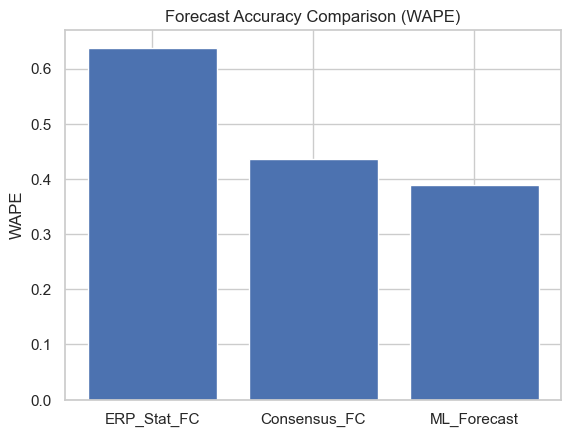

In [121]:
plt.figure()
plt.bar(labels, values)
plt.title("Forecast Accuracy Comparison (WAPE)")
plt.ylabel("WAPE")
plt.show()

- LESS IS THE VALUE MORE IS THE WAPE 


## Future Enhancements

- Include time-series features such as month, seasonality, and lagged demand.
- Develop separate models for high-volume and low-volume products.
- Improve promotion uplift modeling using historical campaign data.
- Explore advanced models if needed, while maintaining interpretability.

##  Conclusion

The analysis demonstrates that Statistical Forecast alone is insufficient for accurate demand prediction.

Machine Learning significantly improves forecast accuracy by incorporating business-relevant factors.

This leads to better demand planning, reduced stockouts, and improved supply chain efficiency.

A combination of statistical methods and data-driven modeling is recommended for optimal forecasting performance.